# Explanatory Data Analysis (EDA) - Deteksi Lubang Jalan (Pothole Detection)

## Deskripsi Proyek
Proyek ini bertujuan mengembangkan sistem deteksi lubang jalan otomatis berbasis dashcam menggunakan Deep Learning. Dataset ini adalah kumpulan gambar jalan dengan anotasi bounding box untuk lubang jalan yang akan digunakan untuk melatih model deteksi objek YOLOv8.

---

## Preparation

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import yaml
from collections import Counter
from pathlib import Path
import pathlib

from ultralytics import YOLO

import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Krisna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
# Load the YAML file
with open('data/data.yaml', 'r') as f:
    data_yaml = yaml.safe_load(f)

# update YAML with absolute path to kaggle data. You must use absolute path, relative path won't work
data_yaml['train'] = 'data/train/images'
data_yaml['val'] = 'data/valid/images'

# write to disk
with open('data.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

In [36]:
data_dir = Path("data")
images_dir = data_dir / "train" / "images"
labels_dir = data_dir / "train" / "labels"

class_names = data_yaml['names']

# Read the image file paths and annotations
image_paths = list(images_dir.glob("*.jpg"))
label_paths = sorted(labels_dir.glob("*.txt"))

In [37]:
Image_dir = 'data/train/images'

## EDA

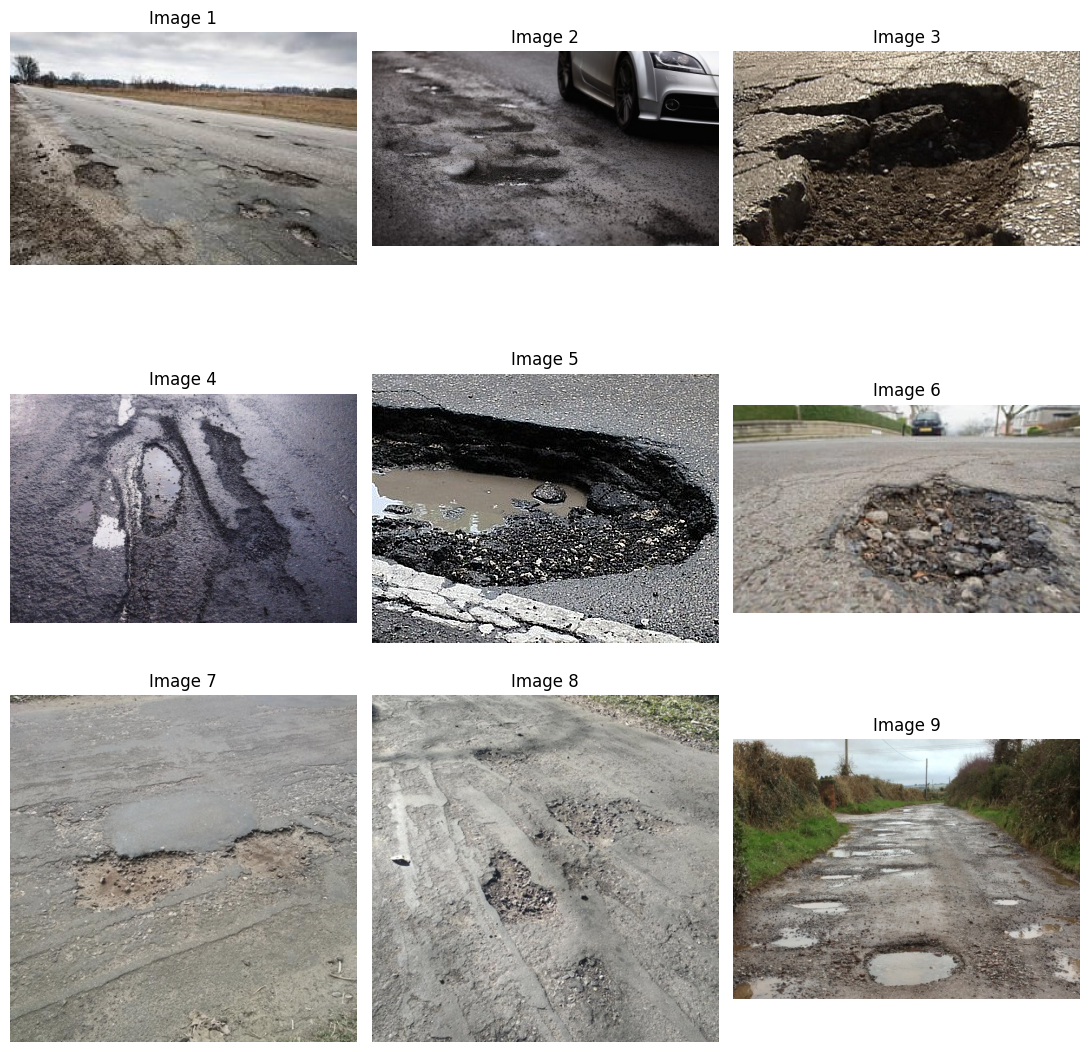

In [38]:
num_samples = 9
image_files = os.listdir(Image_dir)

# Randomly select num_samples images
rand_images = random.sample(image_files, num_samples)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))

for i in range(num_samples):
    image = rand_images[i]
    ax = axes[i // 3, i % 3]
    ax.imshow(plt.imread(os.path.join(Image_dir, image)))
    ax.set_title(f'Image {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [39]:
resolutions = []
failed_images = []

for image_path in image_paths:
    img = cv2.imread(str(image_path))
    
    # Validasi: cek apakah gambar berhasil dibaca
    if img is None:
        failed_images.append(str(image_path))
        continue
    
    h, w, _ = img.shape
    resolutions.append((w, h))

print(f"Total images processed: {len(resolutions)}")
print(f"Failed to read: {len(failed_images)}")

if failed_images:
    print("\nGambar yang gagal dibaca:")
    for img in failed_images[:5]:  # Tampilkan 5 yang pertama
        print(f"  - {img}")

unique_resolutions = set(resolutions)
print(f"\nUnique resolutions: {unique_resolutions}")
print(f"Total unique resolutions: {len(unique_resolutions)}")

Total images processed: 1580
Failed to read: 1

Gambar yang gagal dibaca:
  - data\train\images\pothole_731.jpg

Unique resolutions: {(651, 366), (1200, 1600), (900, 405), (507, 330), (848, 480), (1215, 682), (610, 450), (790, 520), (489, 300), (500, 300), (1200, 800), (300, 400), (800, 448), (819, 974), (980, 653), (451, 300), (462, 300), (639, 360), (450, 600), (432, 286), (530, 300), (1200, 939), (435, 300), (620, 373), (400, 199), (875, 492), (350, 378), (4256, 2832), (590, 350), (1337, 1569), (3264, 1836), (619, 395), (635, 358), (600, 400), (3200, 1680), (350, 234), (980, 648), (300, 224), (3000, 2000), (1086, 815), (454, 300), (466, 274), (680, 383), (420, 316), (462, 569), (1186, 600), (626, 430), (2560, 1441), (756, 378), (436, 269), (907, 510), (1100, 825), (1920, 1080), (1280, 792), (1536, 2048), (1774, 2365), (960, 540), (299, 129), (720, 540), (450, 298), (1140, 754), (1200, 628), (1620, 1080), (550, 412), (1295, 893), (1599, 1057), (503, 300), (2400, 1600), (720, 405), (7


## Analisis Anotasi Dataset (Bounding Boxes)

In [40]:
# Parse label files dan ekstrak informasi bounding box
from pathlib import Path

def parse_yolo_label(label_file, img_width, img_height):
    """
    Parse YOLO format label file
    Format: <class_id> <x_center> <y_center> <width> <height> (normalized 0-1)
    Returns: list of bounding boxes dengan pixel coordinates
    """
    boxes = []
    try:
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id, x_center, y_center, width, height = map(float, parts[:5])
                    
                    # Convert from normalized to pixel coordinates
                    x_center_px = x_center * img_width
                    y_center_px = y_center * img_height
                    width_px = width * img_width
                    height_px = height * img_height
                    
                    # Calculate top-left and bottom-right
                    x_min = x_center_px - width_px / 2
                    y_min = y_center_px - height_px / 2
                    x_max = x_center_px + width_px / 2
                    y_max = y_center_px + height_px / 2
                    
                    boxes.append({
                        'class_id': int(class_id),
                        'x_center': x_center_px,
                        'y_center': y_center_px,
                        'width': width_px,
                        'height': height_px,
                        'area': width_px * height_px,
                        'aspect_ratio': width_px / height_px if height_px > 0 else 0,
                        'x_min': x_min,
                        'y_min': y_min,
                        'x_max': x_max,
                        'y_max': y_max
                    })
    except:
        pass
    return boxes

# Parse semua label files untuk train dan valid
def extract_all_boxes(image_dir, label_dir):
    boxes_list = []
    img_count = 0
    
    for label_path in sorted(label_dir.glob("*.txt")):
        # Cari image yang corresponding
        img_name = label_path.stem + '.jpg'
        img_path = image_dir / img_name
        
        if img_path.exists():
            # Baca ukuran gambar
            img = cv2.imread(str(img_path))
            if img is not None:
                h, w, _ = img.shape
                boxes = parse_yolo_label(label_path, w, h)
                
                if boxes:
                    for box in boxes:
                        boxes_list.append({**box, 'image_name': img_name})
                    img_count += 1
    
    return pd.DataFrame(boxes_list), img_count

# Extract untuk train
train_boxes_df, train_img_count = extract_all_boxes(images_dir, labels_dir)
print(f"Train: {train_img_count} images dengan {len(train_boxes_df)} objects")
print(f"\nSampel data:\n{train_boxes_df.head()}")

Train: 1580 images dengan 5939 objects

Sampel data:
   class_id    x_center    y_center       width     height          area  \
0         0   51.879852   74.440080   44.640072  11.759904    524.962961   
1         0  107.929908   35.360064   98.400096  37.800000   3719.523629   
2         0  161.810136    9.920016   53.519940   9.240048    494.526815   
3         0  138.999888  179.759952  278.000100  72.480096  20149.473936   
4         0  151.299900   82.129896  120.480048  32.039928   3860.172063   

   aspect_ratio       x_min       y_min       x_max       y_max     image_name  
0      3.795955   29.559816   68.560128   74.199888   80.320032  pothole_1.jpg  
1      2.603177   58.729860   16.460064  157.129956   54.260064  pothole_1.jpg  
2      5.792171  135.050166    5.299992  188.570106   14.540040  pothole_1.jpg  
3      3.835537   -0.000162  143.519904  277.999938  216.000000  pothole_1.jpg  
4      3.760310   91.059876   66.109932  211.539924   98.149860  pothole_1.jpg  


In [41]:
# STATISTIK DATASET
print("="*60)
print("STATISTIK DATASET POTHOLE DETECTION")
print("="*60)

total_objects = len(train_boxes_df)
total_images = train_img_count
avg_objects_per_img = total_objects / total_images if total_images > 0 else 0

# Hitung per image
objects_per_image = train_boxes_df.groupby('image_name').size()

print(f"\nJumlah Data:")
print(f"   Total gambar (train): {total_images}")
print(f"   Total objects: {total_objects}")
print(f"   Rata-rata objects/gambar: {avg_objects_per_img:.2f}")

print(f"\nUkuran Bounding Box (pixels):")
print(f"   Lebar - Min: {train_boxes_df['width'].min():.0f}, Max: {train_boxes_df['width'].max():.0f}, Mean: {train_boxes_df['width'].mean():.0f}")
print(f"   Tinggi - Min: {train_boxes_df['height'].min():.0f}, Max: {train_boxes_df['height'].max():.0f}, Mean: {train_boxes_df['height'].mean():.0f}")
print(f"   Area - Min: {train_boxes_df['area'].min():.0f}, Max: {train_boxes_df['area'].max():.0f}, Mean: {train_boxes_df['area'].mean():.0f}")

print(f"\nAspect Ratio (lebar/tinggi):")
print(f"   Min: {train_boxes_df['aspect_ratio'].min():.2f}, Max: {train_boxes_df['aspect_ratio'].max():.2f}, Mean: {train_boxes_df['aspect_ratio'].mean():.2f}")

print(f"\nLokasi Object (x_center %):")
print(f"   Mean: {(train_boxes_df['x_center'].mean() / train_boxes_df['x_center'].max() * 100):.1f}%")
print(f"   Mean (y): {(train_boxes_df['y_center'].mean() / train_boxes_df['y_center'].max() * 100):.1f}%")

print("\n" + "="*60)

STATISTIK DATASET POTHOLE DETECTION

Jumlah Data:
   Total gambar (train): 1580
   Total objects: 5939
   Rata-rata objects/gambar: 3.76

Ukuran Bounding Box (pixels):
   Lebar - Min: 6, Max: 3698, Mean: 177
   Tinggi - Min: 2, Max: 2377, Mean: 75
   Area - Min: 20, Max: 7515327, Mean: 39931

Aspect Ratio (lebar/tinggi):
   Min: 0.15, Max: 27.89, Mean: 3.40

Lokasi Object (x_center %):
   Mean: 9.6%
   Mean (y): 9.3%



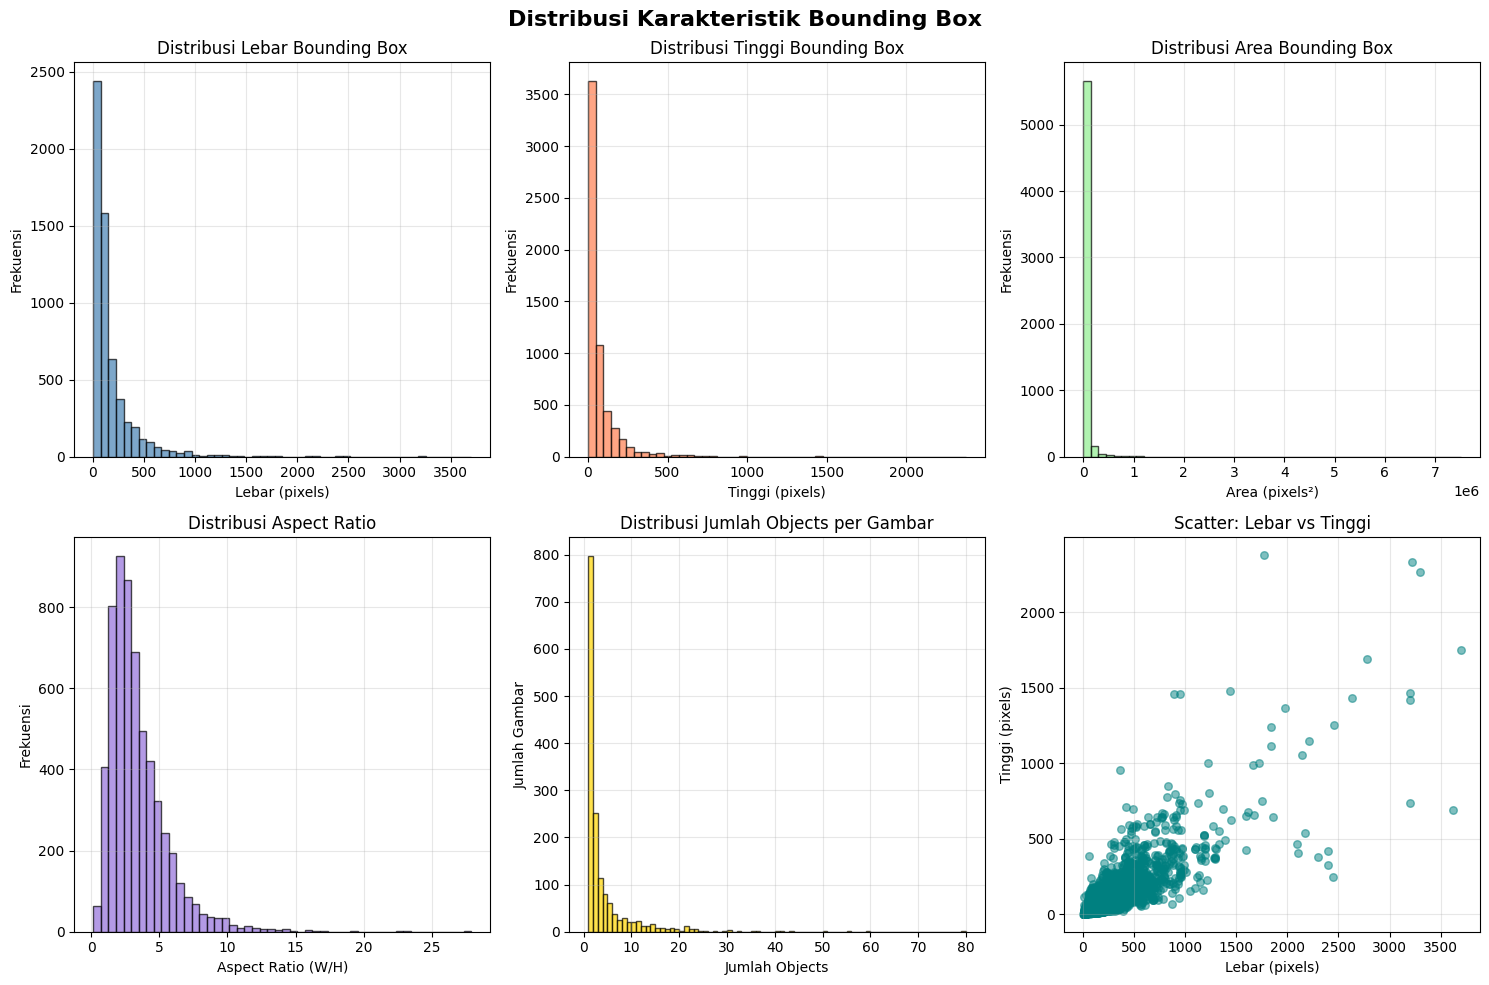


Summary Jumlah Objects per Gambar:
   Min: 1, Max: 79, Mean: 3.76


In [42]:
# VISUALISASI DISTRIBUSI BOUNDING BOX
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribusi Karakteristik Bounding Box', fontsize=16, fontweight='bold')

# Subplot 1: Distribusi Lebar
axes[0, 0].hist(train_boxes_df['width'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Lebar (pixels)')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].set_title('Distribusi Lebar Bounding Box')
axes[0, 0].grid(alpha=0.3)

# Subplot 2: Distribusi Tinggi
axes[0, 1].hist(train_boxes_df['height'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Tinggi (pixels)')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].set_title('Distribusi Tinggi Bounding Box')
axes[0, 1].grid(alpha=0.3)

# Subplot 3: Distribusi Area
axes[0, 2].hist(train_boxes_df['area'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Area (pixels²)')
axes[0, 2].set_ylabel('Frekuensi')
axes[0, 2].set_title('Distribusi Area Bounding Box')
axes[0, 2].grid(alpha=0.3)

# Subplot 4: Distribusi Aspect Ratio
axes[1, 0].hist(train_boxes_df['aspect_ratio'], bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Aspect Ratio (W/H)')
axes[1, 0].set_ylabel('Frekuensi')
axes[1, 0].set_title('Distribusi Aspect Ratio')
axes[1, 0].grid(alpha=0.3)

# Subplot 5: Jumlah Objects per Gambar
objects_count = train_boxes_df.groupby('image_name').size().values
axes[1, 1].hist(objects_count, bins=range(1, max(objects_count)+2), color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Jumlah Objects')
axes[1, 1].set_ylabel('Jumlah Gambar')
axes[1, 1].set_title('Distribusi Jumlah Objects per Gambar')
axes[1, 1].grid(alpha=0.3)

# Subplot 6: Scatter Width vs Height
axes[1, 2].scatter(train_boxes_df['width'], train_boxes_df['height'], alpha=0.5, s=30, color='teal')
axes[1, 2].set_xlabel('Lebar (pixels)')
axes[1, 2].set_ylabel('Tinggi (pixels)')
axes[1, 2].set_title('Scatter: Lebar vs Tinggi')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSummary Jumlah Objects per Gambar:")
print(f"   Min: {objects_count.min()}, Max: {objects_count.max()}, Mean: {objects_count.mean():.2f}")

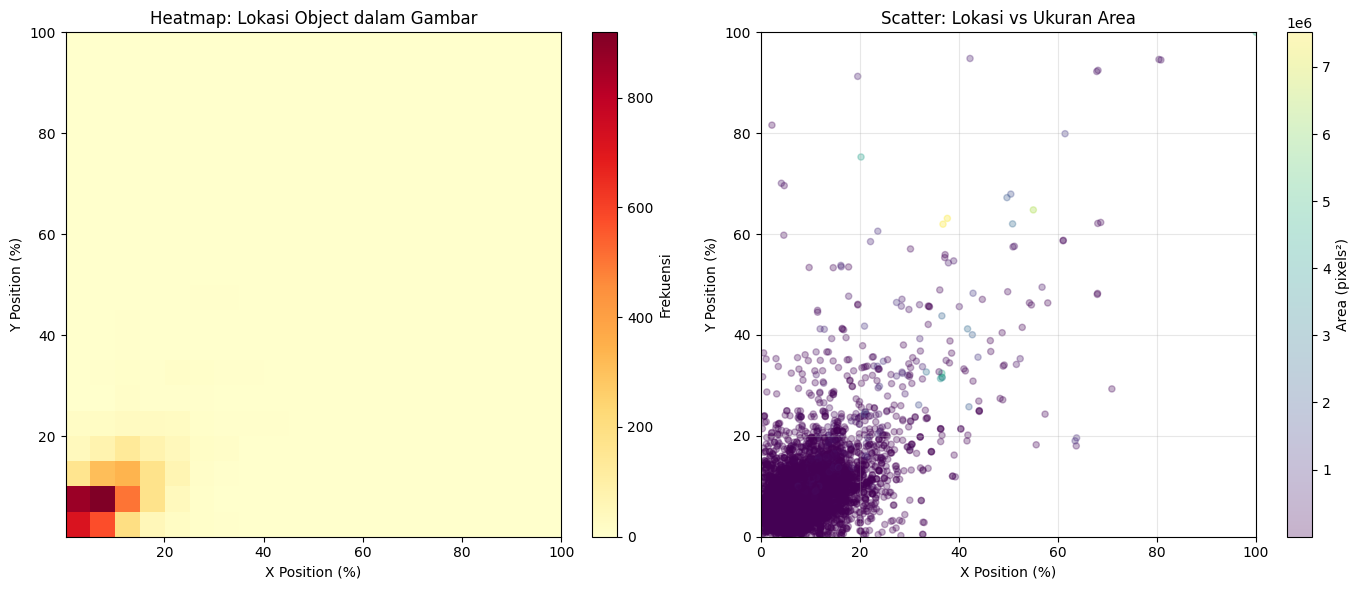


Analisis Lokasi Object:
   X-center - Mean: 9.6%, Std: 7.8%
   Y-center - Mean: 9.3%, Std: 8.1%


In [43]:
# HEATMAP LOKASI OBJECT
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Normalize coordinates ke 0-100 (untuk standardisasi)
x_norm = (train_boxes_df['x_center'] / train_boxes_df['x_center'].max() * 100)
y_norm = (train_boxes_df['y_center'] / train_boxes_df['y_center'].max() * 100)

# Create 2D histogram untuk heatmap
h = axes[0].hist2d(x_norm, y_norm, bins=20, cmap='YlOrRd')
axes[0].set_xlabel('X Position (%)')
axes[0].set_ylabel('Y Position (%)')
axes[0].set_title('Heatmap: Lokasi Object dalam Gambar')
plt.colorbar(h[3], ax=axes[0], label='Frekuensi')

# Scatter plot dengan density
scatter = axes[1].scatter(x_norm, y_norm, alpha=0.3, s=20, c=train_boxes_df['area'], cmap='viridis')
axes[1].set_xlabel('X Position (%)')
axes[1].set_ylabel('Y Position (%)')
axes[1].set_title('Scatter: Lokasi vs Ukuran Area')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)
cbar = plt.colorbar(scatter, ax=axes[1], label='Area (pixels²)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAnalisis Lokasi Object:")
print(f"   X-center - Mean: {x_norm.mean():.1f}%, Std: {x_norm.std():.1f}%")
print(f"   Y-center - Mean: {y_norm.mean():.1f}%, Std: {y_norm.std():.1f}%")

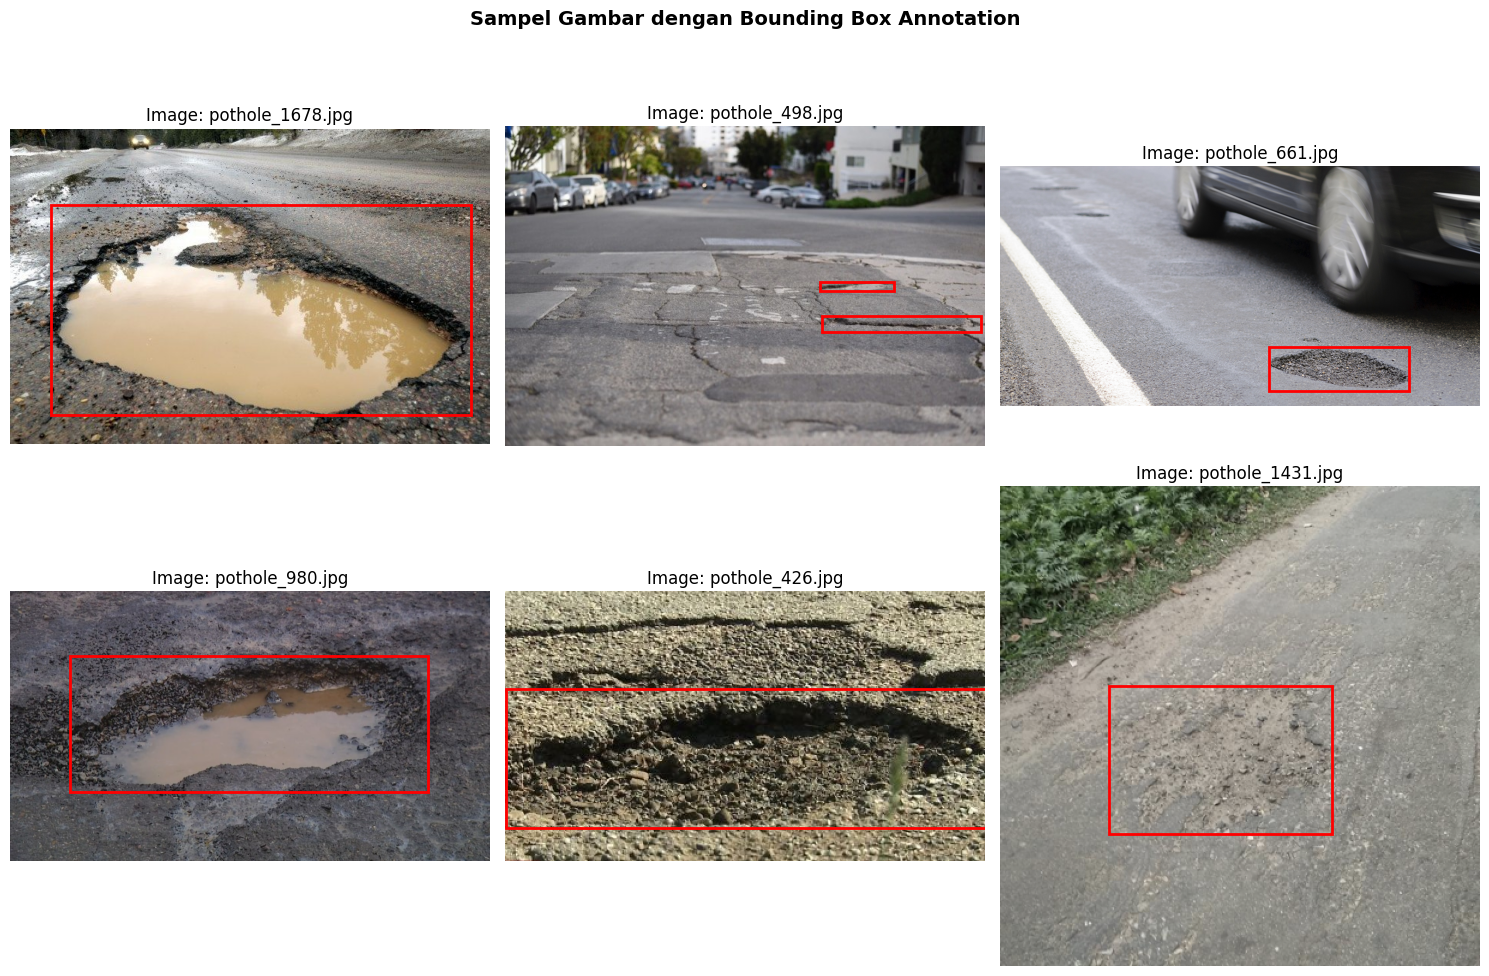

In [44]:
# VISUALISASI GAMBAR DENGAN BOUNDING BOX
def draw_boxes_on_image(image_path, label_path, ax):
    """Draw image dengan bounding boxes"""
    img = cv2.imread(str(image_path))
    if img is None:
        return
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    ax.imshow(img)
    
    # Parse label dan draw boxes
    try:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id, x_center, y_center, width, height = map(float, parts[:5])
                    
                    # Convert ke pixel coordinates
                    x_center_px = x_center * w
                    y_center_px = y_center * h
                    width_px = width * w
                    height_px = height * h
                    
                    x_min = int(x_center_px - width_px / 2)
                    y_min = int(y_center_px - height_px / 2)
                    x_max = int(x_center_px + width_px / 2)
                    y_max = int(y_center_px + height_px / 2)
                    
                    # Draw rectangle
                    from matplotlib.patches import Rectangle
                    rect = Rectangle((x_min, y_min), width_px, height_px, 
                                   linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
    except:
        pass
    
    ax.set_title(f'Image: {image_path.name}')
    ax.axis('off')

# Visualisasi 6 random images dengan bounding boxes
num_samples = 6
sample_labels = random.sample(list(labels_dir.glob("*.txt")), num_samples)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Sampel Gambar dengan Bounding Box Annotation', fontsize=14, fontweight='bold')

for idx, (ax, label_path) in enumerate(zip(axes.flat, sample_labels)):
    img_name = label_path.stem + '.jpg'
    img_path = images_dir / img_name
    
    if img_path.exists():
        draw_boxes_on_image(img_path, label_path, ax)

plt.tight_layout()
plt.show()


Perbandingan Train vs Validation:
           Metric        Train        Valid
     Total Images  1580.000000   395.000000
    Total Objects  5939.000000  1394.000000
Avg Objects/Image     3.758861     3.529114
        Avg Width   177.275683   178.514203
       Avg Height    74.526690    75.304664
         Avg Area 39930.592683 42811.772467
 Avg Aspect Ratio     3.401706     3.264970


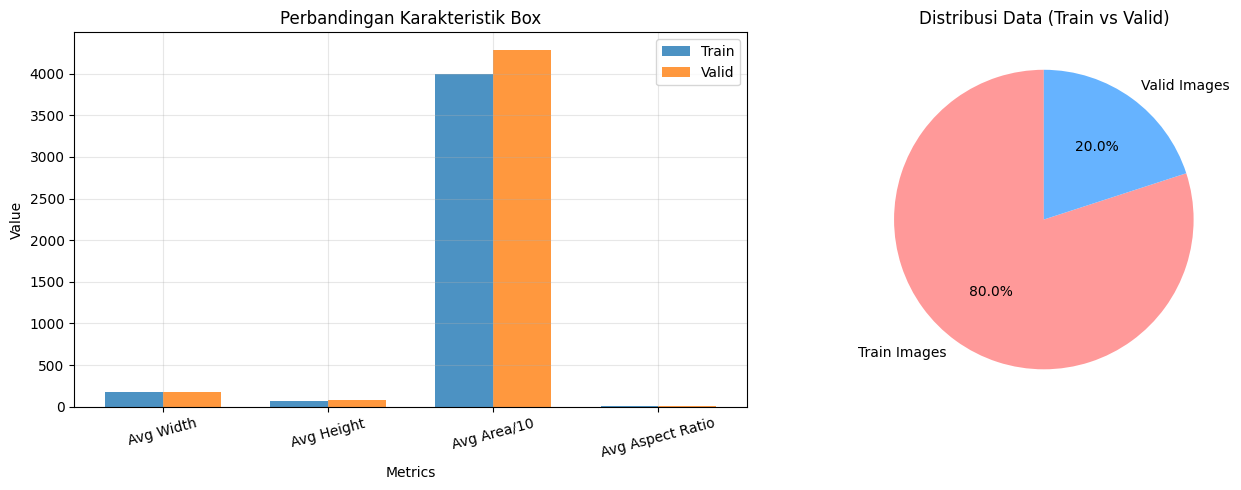

In [45]:
# PERBANDINGAN TRAIN vs VALIDATION SET
# Extract data valid juga
valid_dir = Path("data/valid")
valid_images_dir = valid_dir / "images"
valid_labels_dir = valid_dir / "labels"

valid_boxes_df, valid_img_count = extract_all_boxes(valid_images_dir, valid_labels_dir)

# Buat comparison table
comparison_data = {
    'Metric': ['Total Images', 'Total Objects', 'Avg Objects/Image', 
               'Avg Width', 'Avg Height', 'Avg Area', 'Avg Aspect Ratio'],
    'Train': [
        train_img_count,
        len(train_boxes_df),
        len(train_boxes_df) / train_img_count if train_img_count > 0 else 0,
        train_boxes_df['width'].mean(),
        train_boxes_df['height'].mean(),
        train_boxes_df['area'].mean(),
        train_boxes_df['aspect_ratio'].mean()
    ],
    'Valid': [
        valid_img_count,
        len(valid_boxes_df),
        len(valid_boxes_df) / valid_img_count if valid_img_count > 0 else 0,
        valid_boxes_df['width'].mean(),
        valid_boxes_df['height'].mean(),
        valid_boxes_df['area'].mean(),
        valid_boxes_df['aspect_ratio'].mean()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nPerbandingan Train vs Validation:")
print(comparison_df.to_string(index=False))

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison of distribution
metrics = ['Avg Width', 'Avg Height', 'Avg Area/10', 'Avg Aspect Ratio']
train_vals = [train_boxes_df['width'].mean(), 
              train_boxes_df['height'].mean(), 
              train_boxes_df['area'].mean()/10,
              train_boxes_df['aspect_ratio'].mean()]
valid_vals = [valid_boxes_df['width'].mean(), 
              valid_boxes_df['height'].mean(), 
              valid_boxes_df['area'].mean()/10,
              valid_boxes_df['aspect_ratio'].mean()]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, train_vals, width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, valid_vals, width, label='Valid', alpha=0.8)
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Value')
axes[0].set_title('Perbandingan Karakteristik Box')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Images distribution
labels_comp = ['Train Images', 'Valid Images']
sizes = [train_img_count, valid_img_count]
colors = ['#ff9999', '#66b3ff']
axes[1].pie(sizes, labels=labels_comp, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Distribusi Data (Train vs Valid)')

plt.tight_layout()
plt.show()

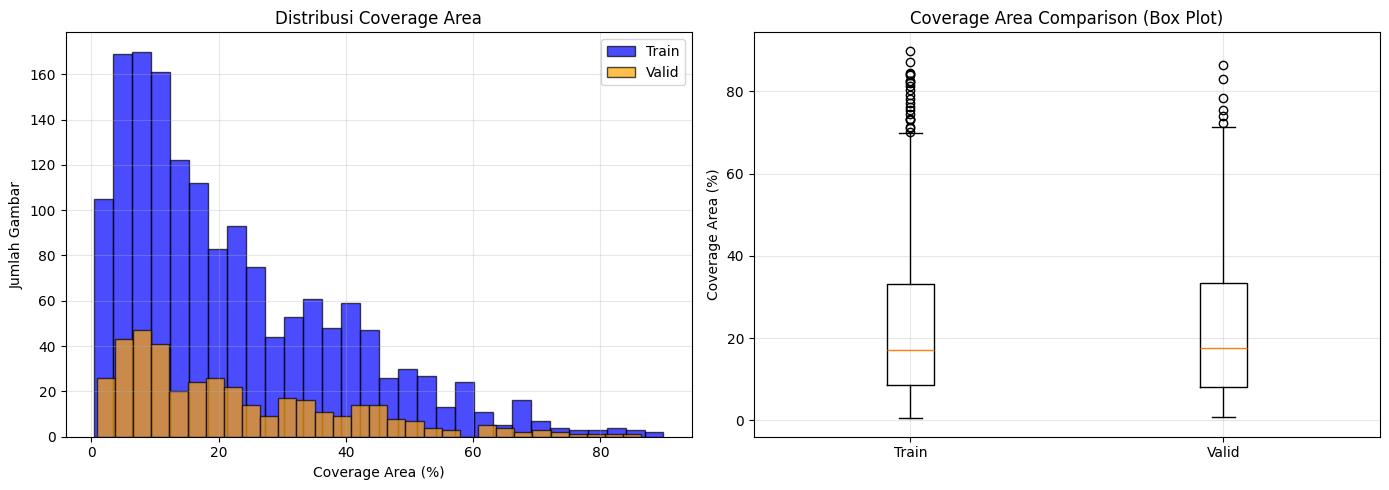


Analisis Coverage Area:
Train - Mean: 22.21%, Std: 17.40%, Min: 0.45%, Max: 89.91%
Valid - Mean: 22.52%, Std: 17.86%, Min: 0.84%, Max: 86.44%


In [46]:
# COVERAGE AREA ANALYSIS
# Hitung coverage area (% gambar yang ditutup object)

def calculate_coverage(image_dir, boxes_df):
    """Hitung persentase area gambar yang ditutup oleh objects"""
    coverage_list = []
    
    for img_name in boxes_df['image_name'].unique():
        img_path = image_dir / img_name
        img = cv2.imread(str(img_path))
        
        if img is not None:
            h, w, _ = img.shape
            total_area = h * w
            
            # Sum area dari semua boxes di gambar ini
            img_boxes = boxes_df[boxes_df['image_name'] == img_name]
            total_box_area = img_boxes['area'].sum()
            
            coverage_pct = (total_box_area / total_area) * 100
            coverage_list.append(coverage_pct)
    
    return coverage_list

train_coverage = calculate_coverage(images_dir, train_boxes_df)
valid_coverage = calculate_coverage(valid_images_dir, valid_boxes_df)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_coverage, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0].hist(valid_coverage, bins=30, alpha=0.7, label='Valid', color='orange', edgecolor='black')
axes[0].set_xlabel('Coverage Area (%)')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_title('Distribusi Coverage Area')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot comparison
axes[1].boxplot([train_coverage, valid_coverage], labels=['Train', 'Valid'])
axes[1].set_ylabel('Coverage Area (%)')
axes[1].set_title('Coverage Area Comparison (Box Plot)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAnalisis Coverage Area:")
print(f"Train - Mean: {np.mean(train_coverage):.2f}%, Std: {np.std(train_coverage):.2f}%, Min: {np.min(train_coverage):.2f}%, Max: {np.max(train_coverage):.2f}%")
print(f"Valid - Mean: {np.mean(valid_coverage):.2f}%, Std: {np.std(valid_coverage):.2f}%, Min: {np.min(valid_coverage):.2f}%, Max: {np.max(valid_coverage):.2f}%")

## 📊 Perbandingan Data Distribution (Train vs Validation)

📊 RINGKASAN PERBANDINGAN DATA TRAIN vs VALIDATION

🖼️  JUMLAH GAMBAR:
   Train: 1,580 gambar (80.0%)
   Valid: 395 gambar (20.0%)
   Total: 1,975 gambar

🎯 JUMLAH OBJECTS (Pothole):
   Train: 5,939 objects (81.0%)
   Valid: 1,394 objects (19.0%)
   Total: 7,333 objects

📈 RATA-RATA OBJECTS PER GAMBAR:
   Train: 3.76 objects/gambar
   Valid: 3.53 objects/gambar



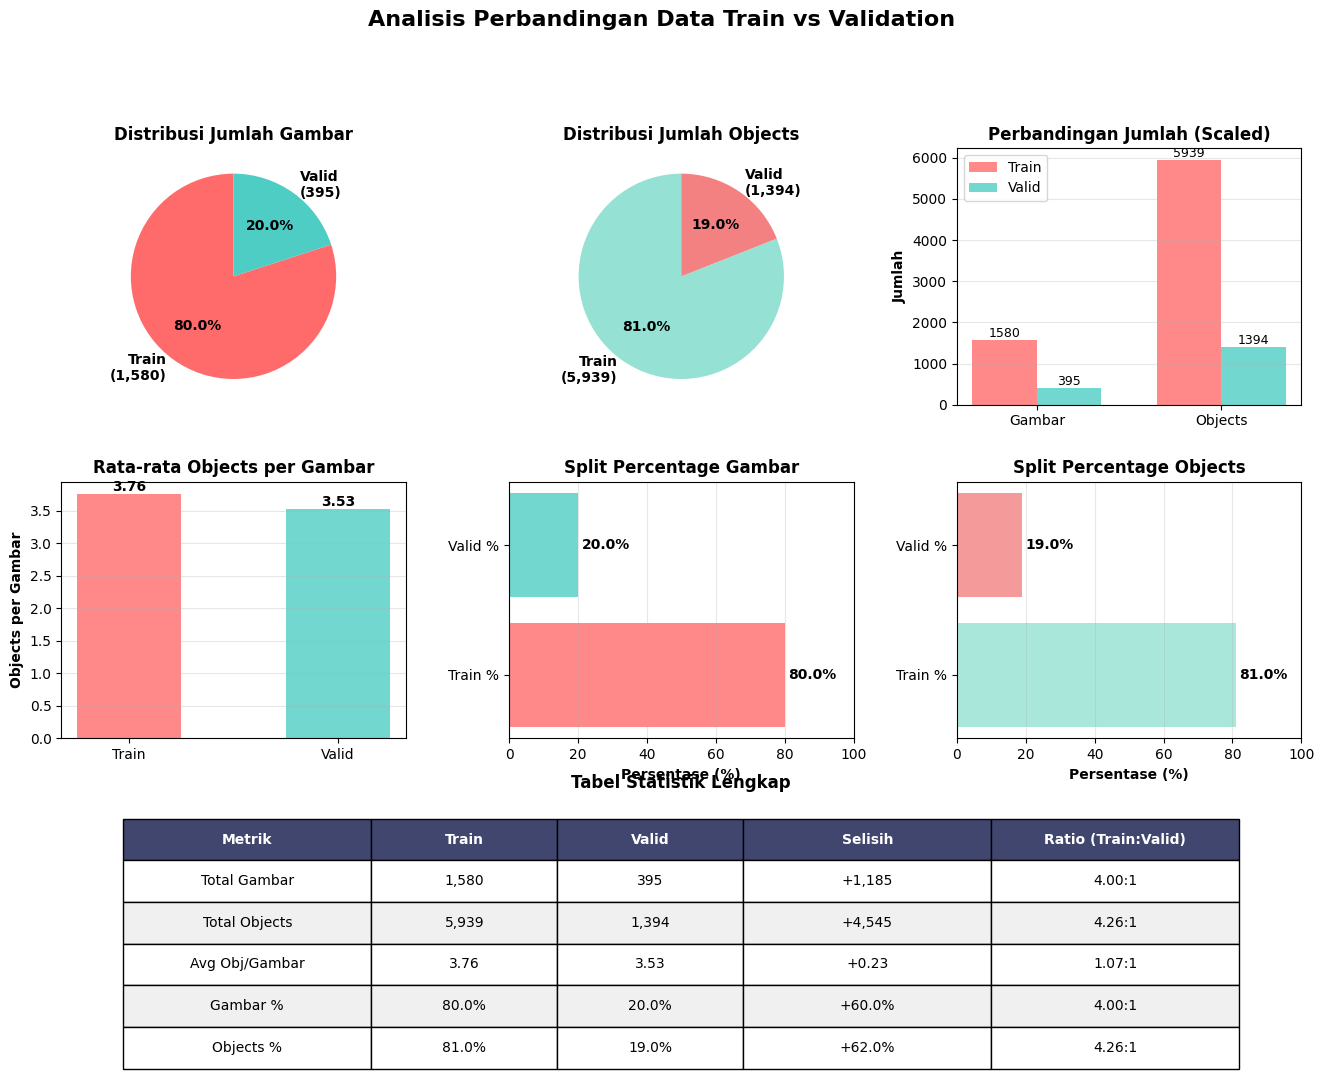


✅ REKOMENDASI DATA SPLIT:
   ✓ Split 80:20 sudah IDEAL untuk train:valid
   ✓ Distribusi objects per gambar SEIMBANG antara train dan valid


In [47]:
# DATA DISTRIBUTION SUMMARY
total_train_images = train_img_count
total_valid_images = valid_img_count
total_all_images = total_train_images + total_valid_images

total_train_objects = len(train_boxes_df)
total_valid_objects = len(valid_boxes_df)
total_all_objects = total_train_objects + total_valid_objects

train_percentage = (total_train_images / total_all_images) * 100
valid_percentage = (total_valid_images / total_all_images) * 100

train_objects_pct = (total_train_objects / total_all_objects) * 100
valid_objects_pct = (total_valid_objects / total_all_objects) * 100

# Print summary
print("="*70)
print("📊 RINGKASAN PERBANDINGAN DATA TRAIN vs VALIDATION")
print("="*70)

print("\n🖼️  JUMLAH GAMBAR:")
print(f"   Train: {total_train_images:,} gambar ({train_percentage:.1f}%)")
print(f"   Valid: {total_valid_images:,} gambar ({valid_percentage:.1f}%)")
print(f"   Total: {total_all_images:,} gambar")

print("\n🎯 JUMLAH OBJECTS (Pothole):")
print(f"   Train: {total_train_objects:,} objects ({train_objects_pct:.1f}%)")
print(f"   Valid: {total_valid_objects:,} objects ({valid_objects_pct:.1f}%)")
print(f"   Total: {total_all_objects:,} objects")

print("\n📈 RATA-RATA OBJECTS PER GAMBAR:")
train_avg = total_train_objects / total_train_images if total_train_images > 0 else 0
valid_avg = total_valid_objects / total_valid_images if total_valid_images > 0 else 0
print(f"   Train: {train_avg:.2f} objects/gambar")
print(f"   Valid: {valid_avg:.2f} objects/gambar")

print("\n" + "="*70)

# Create visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Pie chart untuk distribusi gambar
ax1 = fig.add_subplot(gs[0, 0])
sizes_img = [total_train_images, total_valid_images]
labels_img = [f'Train\n({total_train_images:,})', f'Valid\n({total_valid_images:,})']
colors_img = ['#FF6B6B', '#4ECDC4']
ax1.pie(sizes_img, labels=labels_img, autopct='%1.1f%%', colors=colors_img, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
ax1.set_title('Distribusi Jumlah Gambar', fontsize=12, fontweight='bold')

# 2. Pie chart untuk distribusi objects
ax2 = fig.add_subplot(gs[0, 1])
sizes_obj = [total_train_objects, total_valid_objects]
labels_obj = [f'Train\n({total_train_objects:,})', f'Valid\n({total_valid_objects:,})']
colors_obj = ['#95E1D3', '#F38181']
ax2.pie(sizes_obj, labels=labels_obj, autopct='%1.1f%%', colors=colors_obj, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
ax2.set_title('Distribusi Jumlah Objects', fontsize=12, fontweight='bold')

# 3. Bar chart comparison
ax3 = fig.add_subplot(gs[0, 2])
categories = ['Gambar', 'Objects']
train_vals = [total_train_images, total_train_objects]
valid_vals = [total_valid_images, total_valid_objects]
x = np.arange(len(categories))
width = 0.35
ax3.bar(x - width/2, train_vals, width, label='Train', color='#FF6B6B', alpha=0.8)
ax3.bar(x + width/2, valid_vals, width, label='Valid', color='#4ECDC4', alpha=0.8)
ax3.set_ylabel('Jumlah', fontsize=10, fontweight='bold')
ax3.set_title('Perbandingan Jumlah (Scaled)', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(categories)
ax3.legend()
ax3.grid(alpha=0.3, axis='y')
for i, v in enumerate(train_vals):
    ax3.text(i - width/2, v, str(v), ha='center', va='bottom', fontsize=9)
for i, v in enumerate(valid_vals):
    ax3.text(i + width/2, v, str(v), ha='center', va='bottom', fontsize=9)

# 4. Ratio analysis
ax4 = fig.add_subplot(gs[1, 0])
ratio_data = [train_avg, valid_avg]
bars = ax4.bar(['Train', 'Valid'], ratio_data, color=['#FF6B6B', '#4ECDC4'], alpha=0.8, width=0.5)
ax4.set_ylabel('Objects per Gambar', fontsize=10, fontweight='bold')
ax4.set_title('Rata-rata Objects per Gambar', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Data quality metric - Train/Valid balance
ax5 = fig.add_subplot(gs[1, 1])
balance_train_img = 100 - train_percentage
balance_valid_img = 100 - valid_percentage
metrics_balance = ['Train %', 'Valid %']
balance_vals = [train_percentage, valid_percentage]
colors_balance = ['#FF6B6B', '#4ECDC4']
ax5.barh(metrics_balance, balance_vals, color=colors_balance, alpha=0.8)
ax5.set_xlabel('Persentase (%)', fontsize=10, fontweight='bold')
ax5.set_title('Split Percentage Gambar', fontsize=12, fontweight='bold')
ax5.set_xlim(0, 100)
ax5.grid(alpha=0.3, axis='x')
for i, v in enumerate(balance_vals):
    ax5.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

# 6. Objects balance
ax6 = fig.add_subplot(gs[1, 2])
metrics_obj = ['Train %', 'Valid %']
obj_vals = [train_objects_pct, valid_objects_pct]
ax6.barh(metrics_obj, obj_vals, color=['#95E1D3', '#F38181'], alpha=0.8)
ax6.set_xlabel('Persentase (%)', fontsize=10, fontweight='bold')
ax6.set_title('Split Percentage Objects', fontsize=12, fontweight='bold')
ax6.set_xlim(0, 100)
ax6.grid(alpha=0.3, axis='x')
for i, v in enumerate(obj_vals):
    ax6.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

# 7. Detailed statistics table
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('tight')
ax7.axis('off')

stats_table_data = [
    ['Metrik', 'Train', 'Valid', 'Selisih', 'Ratio (Train:Valid)'],
    ['Total Gambar', f'{total_train_images:,}', f'{total_valid_images:,}', 
     f'{total_train_images - total_valid_images:+,}', f'{total_train_images/total_valid_images:.2f}:1'],
    ['Total Objects', f'{total_train_objects:,}', f'{total_valid_objects:,}', 
     f'{total_train_objects - total_valid_objects:+,}', f'{total_train_objects/total_valid_objects:.2f}:1'],
    ['Avg Obj/Gambar', f'{train_avg:.2f}', f'{valid_avg:.2f}', 
     f'{train_avg - valid_avg:+.2f}', f'{train_avg/valid_avg:.2f}:1' if valid_avg > 0 else 'N/A'],
    ['Gambar %', f'{train_percentage:.1f}%', f'{valid_percentage:.1f}%', 
     f'{train_percentage - valid_percentage:+.1f}%', f'{train_percentage/valid_percentage:.2f}:1'],
    ['Objects %', f'{train_objects_pct:.1f}%', f'{valid_objects_pct:.1f}%', 
     f'{train_objects_pct - valid_objects_pct:+.1f}%', f'{train_objects_pct/valid_objects_pct:.2f}:1'],
]

table = ax7.table(cellText=stats_table_data, cellLoc='center', loc='center',
                 colWidths=[0.2, 0.15, 0.15, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(stats_table_data)):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax7.set_title('Tabel Statistik Lengkap', fontsize=12, fontweight='bold', pad=20)

plt.suptitle('Analisis Perbandingan Data Train vs Validation', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Recommendation based on data split
print("\n✅ REKOMENDASI DATA SPLIT:")
if abs(train_percentage - 80) < 5:
    print("   ✓ Split 80:20 sudah IDEAL untuk train:valid")
elif train_percentage > 85:
    print("   ⚠️  Train set terlalu besar, pertimbangkan rebalance ke 80:20")
else:
    print("   ⚠️  Train set terlalu kecil, tambahkan lebih banyak training data")

if abs(train_avg - valid_avg) / valid_avg * 100 < 10:
    print("   ✓ Distribusi objects per gambar SEIMBANG antara train dan valid")
else:
    print("   ⚠️  Ada ketidakseimbangan dalam distribusi objects per gambar")